In [1]:
from FSC import *
import mrcfile
import time
import pandas as pd
import os
from resolution_measure_mrc import *
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42 # Formatting for editable pdf text
matplotlib.rcParams['font.sans-serif']=['Arial']
import math

figs_dir = '/Users/atk42/OneDrive - Yale University/Kuan Lab Shared/Projects/TEM_tomo/fig_panels/'
thick_pal={'1000nm':'#fe4a49','750nm':'#2ab7ca','500nm':'#fed766'}
thick_pal={'1000nm':'#0077BB','750nm':'#009988','500nm':'#EE7733'}
#https://personal.sron.nl/~pault/
def import_fsc_results(output_dir, tomo_lst, num_angs, max_angs, constant_density = False):
    df = pd.read_csv(tomo_lst)
    all_fsc = dict()
    #pd.DataFrame()
    for ref in ['a','b']: # 250620 currently, a and b are the same, so this is redundant
        all_fsc[ref] = pd.DataFrame()
        for index,row in df.iterrows():
            proj = 'microscopy_%i' % int(row['MPID'])
            tomo = row['Tomogram']
            thickness = row['Thickness']
            pixel_size = row['Pixel Size bin 4 (nm)']
        
            for idx,num_ang in enumerate(num_angs):
                if constant_density:
                    max_angs_load = [max_angs[idx]]
                else:
                    max_angs_load = max_angs
                for max_ang in max_angs_load:
                    if num_ang == 121 and max_ang == 10:
                        continue
                    #ofn = os.sep.join([output_dir, 'FSC3D_ref%s_%s_%s_%i-limited[%.1f_-%.1f].csv' % (ref, thickness, tomo,num_ang,max_ang,max_ang)])
                    ofn = os.sep.join([output_dir, 'FSC2D_%s_%s_%i-limited[%.1f_-%.1f].csv' % (thickness, tomo,num_ang,max_ang,max_ang)])
                    
                    fsc_df = pd.read_csv(ofn,header=None,names = ['z','x','y','res','mean','corr'])
                    fsc_df['thickness'] = thickness
                    fsc_df['pixel_size'] = float(pixel_size)
                    fsc_df['name'] = tomo
                    fsc_df['num_ang'] = int(num_ang)
                    fsc_df['max_ang'] = int(max_ang)
                    fsc_df['plane'] = '3d'
                    #fsc_df['fsc_resolution'] = [float(i[0:6]) for i in fsc_df['res'].values]
                    fsc_df['fsc_resolution'] = [float(i) for i in fsc_df['res'].values]
                    fsc_df['correlation'] = [float(i) for i in fsc_df['corr'].values]
                    all_fsc[ref] = pd.concat([all_fsc[ref], fsc_df])
    return all_fsc

def average_dfs(df1, df2, exclude_cols = None):

    # Identifying numeric columns
    numeric_cols = df1.select_dtypes(include=[np.number]).columns

    # Averaging numeric columns
    average_df = (df1[numeric_cols] + df2[numeric_cols]) / 2

    # Handling non-numeric columns
    for col in df1.columns:
        if col not in exclude_cols:
            if col not in numeric_cols:
                if (df1[col] == df2[col]).all():
                    average_df[col] = df1[col]
                else:
                    raise ValueError(f"Non-matching values found in column {col}")
    return average_df

def calculate_e_xz(alpha_deg):
    # Convert degrees to radians
    alpha_rad = math.radians(alpha_deg)
    
    # Compute numerator and denominator
    numerator = alpha_rad + math.sin(alpha_rad) * math.cos(alpha_rad)
    denominator = alpha_rad - math.sin(alpha_rad) * math.cos(alpha_rad)
    
    # Check for division by zero
    if denominator == 0:
        raise ValueError("Denominator is zero. e_xz is undefined for this alpha.")
    
    # Compute e_xz
    e_xz = math.sqrt(numerator / denominator)
    return e_xz

In [2]:
# Load FSC results from csv outputs from dtilt_ref_calc_tomo_FSCs.py
num_angs = [121,33,21,17,11,5]
max_angs = [10,20,30,40,50,60]

# 3.3k mag
tomo_lst_3k = 'tomo_lists/tomograms_lst - double_tilt_tomos_3.3k.csv'


output_dir_3k = 'results/250703_3k_2D_incr_abHalfBit315_45pix_4x'
fscs_3k= import_fsc_results(output_dir_3k, tomo_lst_3k, num_angs, max_angs, constant_density=False)

# Average "a" and "b" reference calculations (to make symmetrical)
# 251023 now, a and b are the same 
all_fsc_3k = average_dfs(fscs_3k['a'],fscs_3k['b'], exclude_cols=['res','corr'])

# Include thickness 0.5, .75 and 1 um
all_fsc_3k = all_fsc_3k[all_fsc_3k['thickness'].isin(['500nm','750nm','1000nm'])]

tomo_lst_11k = 'tomo_lists/tomograms_lst - double_tilt_tomos_11k.csv'
output_dir_11k = 'results/250624_11k_2D_incr_abHalfBit315_45pix_4x'

fscs_11k= import_fsc_results(output_dir_11k, tomo_lst_11k, num_angs, max_angs, constant_density=False)
# Average "a" and "b" reference calculations (to make symmetrical)
all_fsc_11k = average_dfs(fscs_11k['a'],fscs_11k['b'], exclude_cols=['res','corr'])
# Include thickness 0.5, .75 and 1 um
all_fsc_11k = all_fsc_11k[all_fsc_11k['thickness'].isin(['500nm','750nm','1000nm'])]


[  5.  11.  17.  21.  33. 121.]
500nm: 12.2 ± 1.80 nm
500nm: n = 726 subvolumes across 3 tomograms
750nm: 13.2 ± 1.19 nm
750nm: n = 726 subvolumes across 2 tomograms
1000nm: 15.5 ± 0.59 nm
1000nm: n = 968 subvolumes across 2 tomograms


/Users/atk42/envs/tem_tomo/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/atk42/envs/tem_tomo/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/atk42/envs/tem_tomo/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


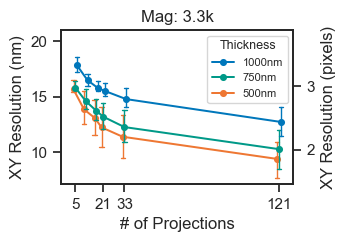

In [15]:
# Main Plot for FSC res vs # projections 
# Fig. 1e
max_ang = 30 # Plot for +- 30 deg
mag = '3.3k'
#mag = '11k'
if mag == '3.3k':
    my_df = all_fsc_3k
elif mag == '11k':
    my_df = all_fsc_11k

my_df = my_df[my_df['max_ang']==max_ang]
[print(np.unique(my_df.num_ang))]
pixel_size = my_df['pixel_size'].values[0]


sns.set_theme(rc={'figure.figsize':(3,2),'lines.linewidth':0.8},style = 'ticks')

my_df = my_df[my_df['fsc_resolution']>0] # remove outlier cubes


g = sns.pointplot(my_df,x='num_ang', y = 'fsc_resolution', hue='thickness', estimator='mean',
            errorbar=('pi',50), 
            #errorbar = ('ci', 95),
            native_scale=True, dodge = 0.5, palette=thick_pal,
            log_scale = False,  markersize = 4, capsize = .6,
            err_kws={'linewidth':1})

handles, labels = g.get_legend_handles_labels()
order = [2,1,0]
#g.legend().remove()
#g.legend([handles[idx] for idx in order],[labels[idx] for idx in order],
#         title = 'Thickness', bbox_to_anchor=(-0.3, -.8), loc='lower left',ncol=3)

g.legend([handles[idx] for idx in order],[labels[idx] for idx in order],fontsize=8,
         title = 'Thickness', title_fontsize=9, loc='upper right')
#g.axhline(y=2*pixel_size, color = 'k', linestyle = '--')
g.set_xlabel('# of Projections')
g.set_ylabel('XY Resolution (nm)')
g.set_title('Mag: %s' % mag)#, ha='left', x = 0.1)
#g.grid(axis='y', color = 'k', linewidth=0.5)
#g.set_ylim([10,g.get_ylim()[1]])

num_angs_labels = [5 , 21, 33, 121]
g.set_xticks(num_angs_labels)
g.set_xticklabels(num_angs_labels)

y1, y2 = g.get_ylim()
g.set_ylim(y1, 21)
g.set_yticks([10, 15, 20])

ax2 = g.twinx()

ax2.set_ylim(y1/pixel_size, y2/pixel_size)
ax2.set_yticks([2,3])
ax2.set_ylabel('XY Resolution (pixels)')
#sns.despine()

num_ang = 21
for thickness in my_df.thickness.unique():
    test_df = my_df[my_df.thickness == thickness]
    test_df = test_df[test_df.num_ang == num_ang]
    
    print('%s: %0.1f ± %0.2f nm' % (thickness,np.mean(test_df.fsc_resolution.values),stats.iqr(test_df.fsc_resolution.values)/2))
    print('%s: n = %i subvolumes across %i tomograms' % (thickness,len(test_df.fsc_resolution.values),len(np.unique(test_df.name))))

#plt.savefig(figs_dir + '251023_rev1_Fig1e_Numang_FSCres_thickness_2D_%s.pdf' % mag, bbox_inches = 'tight')


/Users/atk42/envs/tem_tomo/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/atk42/envs/tem_tomo/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/atk42/envs/tem_tomo/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


500nm: 4.4 ± 0.14 nm
500nm: 4.4 ± 0.14 nm
500nm: n = 594 subvolumes across 1 tomograms
750nm: 4.5 ± 0.09 nm
750nm: 4.5 ± 0.09 nm
750nm: n = 1089 subvolumes across 1 tomograms
1000nm: 4.8 ± 0.09 nm
1000nm: 4.8 ± 0.09 nm
1000nm: n = 1448 subvolumes across 1 tomograms


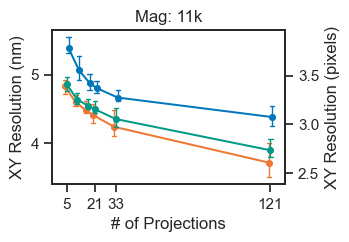

In [ ]:
# Main Plot for FSC res vs # projections 
# Fig. 1f
max_ang = 30  # Plot for +- 30 deg
mag = '11k'
if mag == '3.3k':
    my_df = all_fsc_3k
elif mag == '11k':
    my_df = all_fsc_11k
my_df = my_df[my_df['max_ang']==max_ang]
pixel_size = my_df['pixel_size'].values[0]

sns.set_theme(rc={'figure.figsize':(3,2),'lines.linewidth':0.8},style = 'ticks')

my_df = my_df[my_df['fsc_resolution']>0] # remove outlier cubes
g = sns.pointplot(my_df,x='num_ang', y = 'fsc_resolution', hue='thickness', estimator='mean',
            errorbar=('pi',50), 
            #errorbar = ('ci', 95),
            native_scale=True, dodge = 0.5, palette=thick_pal,
            log_scale = False,  markersize = 4, capsize = .6,
            err_kws={'linewidth':1})

handles, labels = g.get_legend_handles_labels()
order = [2,1,0]
#g.legend([handles[idx] for idx in order],[labels[idx] for idx in order],
#         title = 'Thickness', bbox_to_anchor=(.5, .7), loc='lower left',ncol=1)
#g.axhline(y=2*pixel_size, color = 'k', linestyle = '--')
g.legend().remove()
g.set_xlabel('# of Projections')
g.set_ylabel('XY Resolution (nm)')
g.set_title('Mag: %s' % mag)#, ha='left', x = 0.1)
#g.grid(axis='y', color = 'k', linewidth=0.5)
#g.set_ylim([10,g.get_ylim()[1]])

num_angs_labels = [5 , 21, 33, 121]
g.set_xticks(num_angs_labels)
g.set_xticklabels(num_angs_labels)

g.set_yticks([4,5])
ax2 = g.twinx()
y1, y2 = g.get_ylim()
ax2.set_ylim(y1/pixel_size, y2/pixel_size)
ax2.set_yticks([2.5,3,3.5])
ax2.set_ylabel('XY Resolution (pixels)')

num_ang = 21
for thickness in my_df.thickness.unique():
    test_df = my_df[my_df.thickness == thickness]
    test_df = test_df[test_df.num_ang == num_ang]
    
    print('%s: %0.1f ± %0.2f nm' % (thickness,np.mean(test_df.fsc_resolution.values),stats.iqr(test_df.fsc_resolution.values)/2)) 
    print('%s: %0.1f ± %0.2f nm' % (thickness,np.mean(test_df.fsc_resolution.values),stats.iqr(test_df.fsc_resolution.values)/2))
    print('%s: n = %i subvolumes across %i tomograms' % (thickness,len(test_df.fsc_resolution.values),len(np.unique(test_df.name))))
#plt.savefig(figs_dir + '251023_rev1_Fig1f_Numang_FSCres_thickness_2D_%s.pdf' % mag, bbox_inches = 'tight')

In [25]:
# Plot example FSC curves
from FSC import *
import mrcfile
import time
import pandas as pd
import os
from resolution_measure_2D_mrc import *
from glob import glob

# Param setup
num_cores = 1
sub_region = [-1, 1890, 1890]
sub_sampling_zxy = [45, 4, 4] # z is slice step
cutout_size = 45 # used by resolution measure 2d 
cube_size = 45 # only used by z_clip (to match legacy 3d fsc FOVs)

# For 2d array, e.g. rev1 Fig 1e,f
num_angs = [21]
max_angs = [30]
plane = 'beam'
output_dir = 'results/260106_plot_FSC_curves'
fake = False

a_path = "/Users/atk42/Library/CloudStorage/OneDrive-YaleUniversity/Kuan Lab Shared/Projects/TEM_tomo/tomo_data/microscopy_5404040/processed_data/MouseCerebellum_A3S1_SA3.3k_de64_tomo10/txbr-backprojection/limited-bin4/21-limited[30.0_-30.0]/MouseCerebellum_A3S1_SA3.3k_de64_tomo10a_z_-94.0.out"

b_path = "/Users/atk42/Library/CloudStorage/OneDrive-YaleUniversity/Kuan Lab Shared/Projects/TEM_tomo/tomo_data/microscopy_5404040/processed_data/MouseCerebellum_A3S1_SA3.3k_de64_tomo10/txbr-backprojection/limited-bin4/21-limited[30.0_-30.0]/MouseCerebellum_A3S1_SA3.3k_de64_tomo10b_z_-94.0.out"

# size is [2069 2068 190]
tomo_size = [2069, 2068, 190]
pixel_size = 4.908

print(a_path)
with mrcfile.open(a_path) as mrc:
    v1 = mrc.data
with mrcfile.open(b_path) as mrc:
    v2 = mrc.data

z,x,y = np.array([tomo_size[2]/2+45, tomo_size[0]/2+45, tomo_size[1]/2], dtype=int)
print(z,x,y)

s = cutout_size
if s > 0:
    if plane == 'beam': # This is plane with the full size images
        center = (z,x+s//2,y+s//2)
        v1c=v1[z,x:x+s,y:y+s]
        v2c=v2[z,x:x+s,y:y+s]

snrt = 0.2071 # half bit threshold
rad_apod = 60 
ax_apod = 60
rt = 6

FSCvol = FSCPlot(v1c,v2c,snrt,rt,rad_apod,ax_apod)
res = pixel_size/FSCvol.get_intersect()

print(res)



/Users/atk42/Library/CloudStorage/OneDrive-YaleUniversity/Kuan Lab Shared/Projects/TEM_tomo/tomo_data/microscopy_5404040/processed_data/MouseCerebellum_A3S1_SA3.3k_de64_tomo10/txbr-backprojection/limited-bin4/21-limited[30.0_-30.0]/MouseCerebellum_A3S1_SA3.3k_de64_tomo10a_z_-94.0.out
140 1079 1034
13.716330585344885


0.3578216469384252


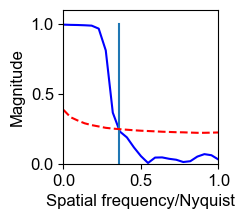

In [27]:
import matplotlib.pyplot as plt
from FSC import *
plt.rcParams["figure.figsize"] = (2, 2) 
plt.rcParams["font.size"] = 12
print(FSCvol.get_intersect())
fig = FSCvol.plot()

plt.legend().remove()
plt.savefig(figs_dir + '260107_rev1_EDFig1_exFSC.pdf', bbox_inches = 'tight')